<a href="https://colab.research.google.com/github/franciscotovar/wtd/blob/main/Workshop1_Motion%20as%20Signal/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## WEARABLE TECH DEVICES  MIET2572
## IMPORTANT

Before starting:

1. Click **File → Save a copy in Drive**
2. Work ONLY on your copy

Do NOT edit the original notebook

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

*   Option A: Generate clean mock signal USE_SYNTHETIC = True
*   Option B: Upload CSV from Phyphox USE_SYNTHETIC = False




In [ ]:
USE_SYNTHETIC = False #True #False

**Data Loading**

In [ ]:
if USE_SYNTHETIC:
    fs = 10  # sampling frequency (Hz)
    duration = 30  # seconds
    t = np.linspace(0, duration, fs*duration)

    step_frequency = 1.8  # Hz (~108 steps/min)
    signal_clean = 1.2 * np.sin(2*np.pi*step_frequency*t)
    noise = 0.2 * np.random.randn(len(t))

    acc_mag = 9.81 + signal_clean + noise  # gravity baseline included

else:
    from google.colab import files
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]

    data = pd.read_csv(filename)

    print(data.columns)  # for debugging
    # Adapt automatically (simple version)
    t  = data.iloc[:,0].values
    ax = data.iloc[:,1].values
    ay = data.iloc[:,2].values
    az = data.iloc[:,3].values

    acc_mag = np.sqrt(ax**2 + ay**2 + az**2)

    fs = 1 / np.mean(np.diff(t))  # estimate sampling rate

**bold text** Plot Raw Signal

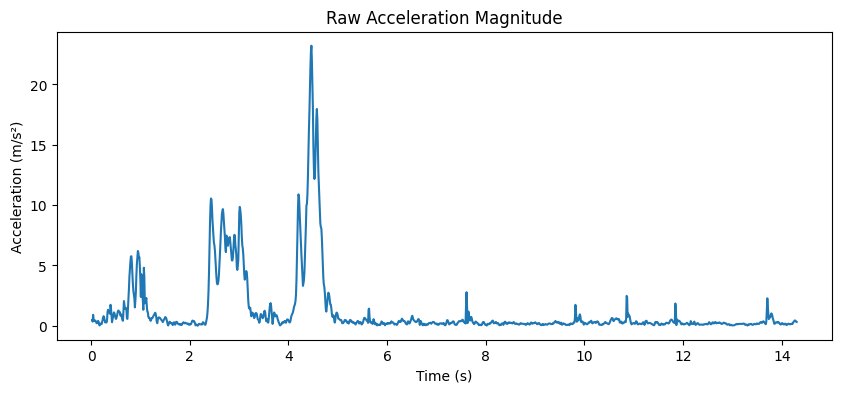

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(t, acc_mag)
plt.title("Raw Acceleration Magnitude")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s²)")
plt.show()

*Smoothing* (with Moving Average)

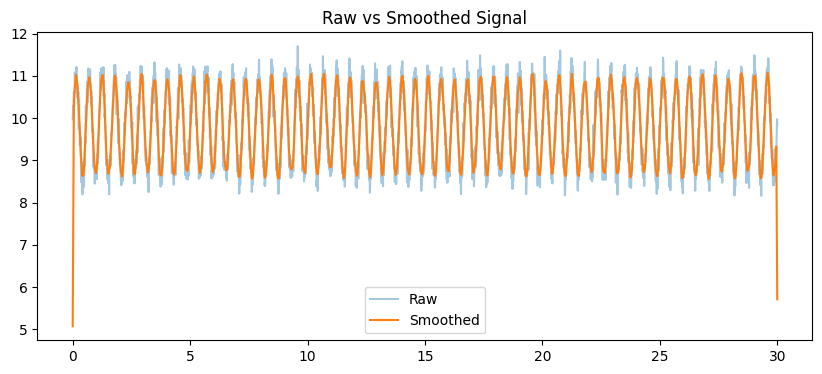

In [ ]:
window_size = int(0.1 * fs)  # 100 ms window
acc_smooth = np.convolve(acc_mag,
                         np.ones(window_size)/window_size,
                         mode='same')

plt.figure(figsize=(10,4))
plt.plot(t, acc_mag, alpha=0.4, label="Raw")
plt.plot(t, acc_smooth, label="Smoothed")
plt.legend()
plt.title("Raw vs Smoothed Signal")
plt.show()

Peak detection

In [ ]:
# ===== MODEL PARAMETERS =====
alpha = 0.25            # amplitude offset above baseline
delta_t_min = 0.4      # minimum time between steps (seconds) # 400 ms physiological constraint

threshold = np.mean(acc_smooth) + alpha
min_distance = int(delta_t_min * fs)


peaks, _ = find_peaks(acc_smooth,
                      height=threshold,
                      distance=min_distance)

step_count = len(peaks)
print("Detected Steps:", step_count)
print(f"Threshold = {threshold:.2f} m/s^2")
print(f"Minimum time between steps = {delta_t_min} s")

Detected Steps: 54
Threshold = 10.05 m/s^2
Minimum time between steps = 0.4 s


Visualize Detected "Events" (Steps)

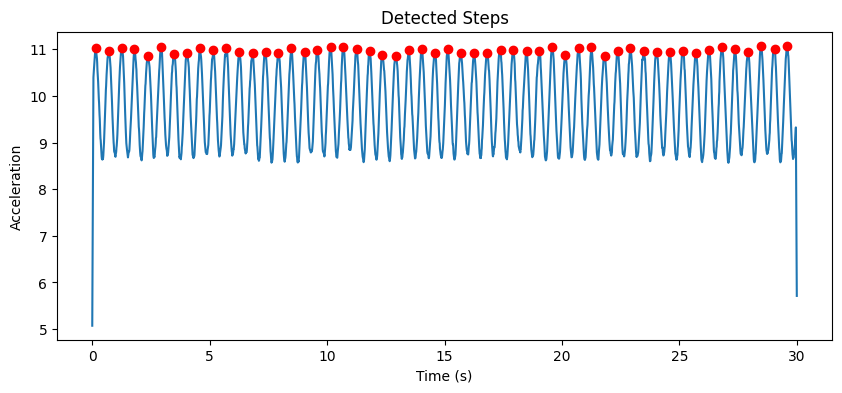

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(t, acc_smooth)
plt.plot(t[peaks], acc_smooth[peaks], "ro")
plt.title("Detected Steps")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration")
plt.show()

Manual vs Algorithm Comparison

In [ ]:
manual_steps = int(input("Enter manual step count: "))
error = step_count - manual_steps

print("Algorithm Steps:", step_count)
print("Manual Steps:", manual_steps)
print("Difference:", error)
print("Percent Error:", 100*error/manual_steps if manual_steps != 0 else "N/A")

KeyboardInterrupt: Interrupted by user

Sensitivity Experiment

In [ ]:
threshold = np.mean(acc_smooth) + 0.2  # lower threshold

peaks2, _ = find_peaks(acc_smooth,
                       height=threshold,
                       distance=min_distance)

print("New Detected Steps:", len(peaks2))